# Customer Segmentation Using RFM and K-Means

### Business objective
The goal is to group customers with similar purchasing behaviour so the business can design more targeted marketing strategies.

### Method in simple terms
- **Customer segmentation** groups customers with similar behaviour.
- **RFM analysis** describes each customer using:
  - **Recency:** how recently the customer purchased.
  - **Frequency:** how many unique orders the customer made.
  - **Monetary:** how much the customer spent.
- **K-Means clustering** groups customers based on their RFM profiles. Customers in the same cluster have similar purchasing patterns.


### Libraries Importation

In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from IPython.display import display, Markdown

import warnings
warnings.filterwarnings("ignore")

In [2]:
sns.set_theme(style = "whitegrid")
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

### Data Importation and Profiling

In [3]:
file_path = "OnlineRetail.xlsx"
excel_file = pd.ExcelFile(file_path)

In [4]:
data = pd.read_excel(file_path, sheet_name = excel_file.sheet_names[0])
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom


In [5]:
data.shape

(541909, 8)

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [7]:
data.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
# missing values, duplicates, uniqueness and data coverage
audit_summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Exact duplicate rows",
        "Unique invoices",
        "Unique products",
        "Unique customers (excluding missing)",
        "Missing CustomerID rows",
        "Missing Description rows",
        "Minimum InvoiceDate",
        "Maximum InvoiceDate",
        "Negative Quantity rows",
        "Zero Quantity rows",
        "Negative UnitPrice rows",
        "Zero UnitPrice rows"
    ],
    "Value": [
        len(data), 
        data.shape[1],
        data.duplicated().sum(),
        data["InvoiceNo"].nunique(),
        data["StockCode"].nunique(),
        data["CustomerID"].nunique(dropna = True), 
        data["CustomerID"].isna().sum(), 
        data["Description"].isna().sum(),
        data["InvoiceDate"].min(),
        data["InvoiceDate"].max(),
        (data["Quantity"] < 0).sum(),
        (data["Quantity"] == 0).sum(),
       (data["UnitPrice"] < 0).sum(),
        (data["UnitPrice"] == 0).sum(),
    ]
    
})
display(audit_summary)

,Metric,Value
0,Rows,541909
1,Columns,8
2,Exact duplicate rows,5268
3,Unique invoices,25900
4,Unique products,4070
5,Unique customers (excluding missing),4372
6,Missing CustomerID rows,135080
7,Missing Description rows,1454
8,Minimum InvoiceDate,2010-12-01 08:26:00
9,Maximum InvoiceDate,2011-12-09 12:50:00


### Audit Summary

The dataset contains **541,909 rows and 8 columns**, covering transactions from **December 2010 to December 2011**. The audit identified **5,268 exact duplicate rows**, **135,080 rows with missing CustomerID**, and **1,454 rows with missing product descriptions**. There were also **10,624 negative-quantity transactions** and **2,515 zero-price transactions**, which may represent returns, cancellations, or adjustments. These data-quality issues were considered during the cleaning stage before performing the RFM analysis.


In [9]:
# Investigating invoice 
data["InvoicePrefix"] = data["InvoiceNo"].astype(str).str[:1]
display(data["InvoicePrefix"].value_counts().to_frame("Rows"))

,Rows
InvoicePrefix,
5,532618
C,9288
A,3


### Invoice Prefix Analysis

The invoice prefix analysis shows that most transactions have no letter prefix, while **C** represents cancelled invoices and **A** represents a small number of adjustment records. These prefixes were reviewed to identify non-standard transactions before filtering the dataset for RFM analysis.

In [10]:
cleaned_data = data.copy()

In [11]:
cleaned_data = cleaned_data.dropna(subset = ["Description", "CustomerID"])

In [12]:
cleaned_data.duplicated().sum()

np.int64(5225)

In [13]:
cleaned_data = cleaned_data.drop_duplicates()

In [14]:
# Keep positive purchase quantities and positive price, this exclude cancellation and adjustment rows.
purchase_data = cleaned_data[
    (cleaned_data["Quantity"] > 0) & (cleaned_data["UnitPrice"] > 0) 
    # Select rows where the invoice does not start with C
    & (~cleaned_data["InvoiceNo"].astype(str).str.startswith("C"))
]

### Transaction Filtering

Cancellations and transactions with zero or negative quantities or prices were removed to ensure that the analysis was based on valid, completed purchases. Including these records could distort key customer-level metrics such as spending, purchase frequency, and RFM scores by treating returns, cancellations, or adjustment transactions as genuine purchases.

Therefore, returns and cancellations were excluded from the primary RFM segmentation to ensure that the resulting customer profiles accurately reflect completed purchasing behavior.

In [15]:
purchase_data["CustomerID"] = purchase_data["CustomerID"].astype("int")

In [16]:
purchase_data["InvoiceDate"] = pd.to_datetime(purchase_data["InvoiceDate"])

In [17]:
purchase_data["Revenue"] = purchase_data["Quantity"] * purchase_data["UnitPrice"]

In [18]:
purchase_data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoicePrefix,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,5,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,5,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,5,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,5,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,5,20.34


In [19]:
print(f"Final customers: {purchase_data['CustomerID'].nunique():,}")
print(f"Final unique purchase invoices: {purchase_data['InvoiceNo'].nunique():,}")
print(f"Final unique products: {purchase_data['StockCode'].nunique():,}")
print(f"Purchase date range: {purchase_data['InvoiceDate'].min()} to {purchase_data['InvoiceDate'].max()}")

Final customers: 4,338
Final unique purchase invoices: 18,532
Final unique products: 3,665
Purchase date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


In [20]:
purchase_data.info()

<class 'pandas.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   InvoiceNo      392692 non-null  object        
 1   StockCode      392692 non-null  object        
 2   Description    392692 non-null  object        
 3   Quantity       392692 non-null  int64         
 4   InvoiceDate    392692 non-null  datetime64[us]
 5   UnitPrice      392692 non-null  float64       
 6   CustomerID     392692 non-null  int64         
 7   Country        392692 non-null  str           
 8   InvoicePrefix  392692 non-null  str           
 9   Revenue        392692 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(2), object(3), str(2)
memory usage: 33.0+ MB


After removing missing IDs, duplicates, cancellations and non-positive purchases, 392,692 transaction rows remained.

## Exploratory Data Analysis

In [21]:
# Customer-level invoice metrics
customer_invoice = (purchase_data.groupby(["CustomerID", "InvoiceNo"])["Revenue"]
    .sum().reset_index())

In [22]:
customer_metric = customer_invoice.groupby("CustomerID").agg(
    AveragePurchaseValue = ("Revenue", "mean"), # average amount spent per invoice
    PurchaseFrequency = ("InvoiceNo", "nunique"), # number of unique invoices
    CustomerLifetimeValue = ("Revenue", "sum")) # Total historical revenue

customer_metric.head()

,AveragePurchaseValue,PurchaseFrequency,CustomerLifetimeValue
CustomerID,,,
12346,"77,183.60",1,"77,183.60"
12347,615.71,7,"4,310.00"
12348,449.31,4,"1,797.24"
12349,"1,757.55",1,"1,757.55"
12350,334.40,1,334.40


In [23]:
purchase_data[["Quantity", "UnitPrice", "UnitPrice"]].describe()

,Quantity,UnitPrice,UnitPrice
count,"392,692.00","392,692.00","392,692.00"
mean,13.12,3.13,3.13
std,180.49,22.24,22.24
min,1.00,0.00,0.00
25%,2.00,1.25,1.25
50%,6.00,1.95,1.95
75%,12.00,3.75,3.75
max,"80,995.00","8,142.75","8,142.75"


In [24]:
### Trend Analysis
purchase_data["YearMonth"] = purchase_data["InvoiceDate"].dt.to_period("M").astype(str)
purchase_data["YearMonth"].head()

0    2010-12
1    2010-12
2    2010-12
3    2010-12
4    2010-12
Name: YearMonth, dtype: str

In [25]:
monthly_summary = purchase_data.groupby("YearMonth").agg(
    Revenue = ("Revenue", "sum"),
    Transactions = ("InvoiceNo", "nunique"),
    Customers = ("CustomerID", "nunique")
).reset_index()
monthly_summary

,YearMonth,Revenue,Transactions,Customers
0,2010-12,"570,422.73",1400,885
1,2011-01,"568,101.31",987,741
2,2011-02,"446,084.92",997,758
3,2011-03,"594,081.76",1321,974
4,2011-04,"468,374.33",1149,856
5,2011-05,"677,355.15",1555,1056
6,2011-06,"660,046.05",1393,991
7,2011-07,"598,962.90",1331,949
8,2011-08,"644,051.04",1280,935
9,2011-09,"950,690.20",1755,1266


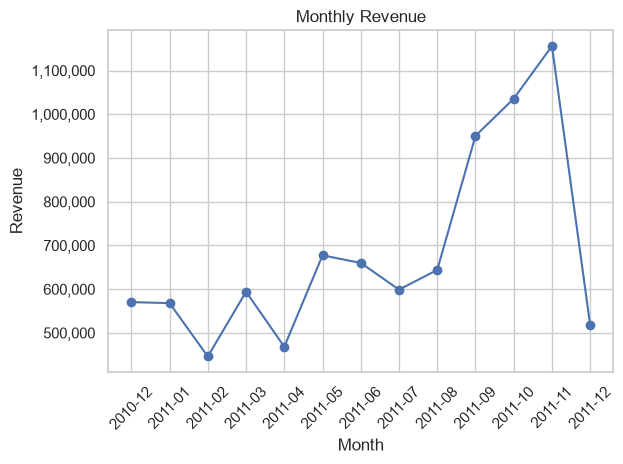

In [26]:
plt.plot(monthly_summary["YearMonth"], monthly_summary["Revenue"], marker = "o")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:,.0f}"))
plt.tick_params(axis = "x", rotation = 45)
plt.tight_layout()
plt.show()

Sales were highest in November but declined sharply in December. This decline is due to the dataset ending on December 9th, meaning December contains only partial-month sales data and therefore is not directly comparable with the full months preceding it.

### RFM Analysis

In [27]:
reference_today = pd.Timestamp.today().normalize()
reference_today

Timestamp('2026-10-07 00:00:00')

In [28]:
reference_date = purchase_data["InvoiceDate"].max() + pd.Timedelta(days = 1)
reference_date

Timestamp('2011-12-10 12:50:00')

Reference Date: Since the dataset represents historical transactions, the reference date was defined as one day after the latest transaction date in the dataset. This provides an appropriate cutoff point for calculating customer recency without introducing bias from the current date.

In [29]:
# Creating RFM features
rfm = (purchase_data.groupby("CustomerID").agg(
    Recency = ("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency = ("InvoiceNo", "nunique"),
    MonetaryValue = ("Revenue", "sum")).reset_index()
)
rfm.head()

,CustomerID,Recency,Frequency,MonetaryValue
0,12346,326,1,"77,183.60"
1,12347,2,7,"4,310.00"
2,12348,75,4,"1,797.24"
3,12349,19,1,"1,757.55"
4,12350,310,1,334.40


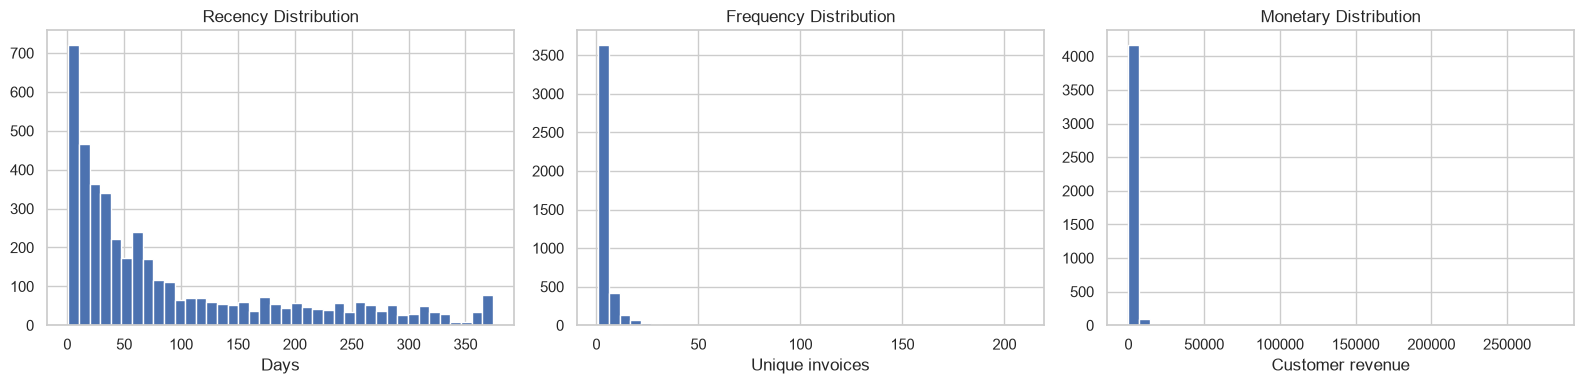

In [30]:
# Customer-level distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(rfm["Recency"], bins = 40)
axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Days")

axes[1].hist(rfm["Frequency"], bins = 40)
axes[1].set_title("Frequency Distribution")
axes[1].set_xlabel("Unique invoices")

axes[2].hist(rfm["MonetaryValue"], bins = 40)
axes[2].set_title("Monetary Distribution")
axes[2].set_xlabel("Customer revenue")

plt.tight_layout()
plt.show()

##  RFM Distribution & Outliers

The customer-level RFM distributions are strongly right-skewed, especially Frequency and Monetary. A small number of customers have many more orders or much higher spending than the typical customer.


### Feature Transformation and Scaling

In [31]:
# Applying log transformation to reduce the effect of skewedness.
rfm_features = rfm[["Recency", "Frequency", "MonetaryValue"]]
log_rfm_features = np.log1p(rfm_features)

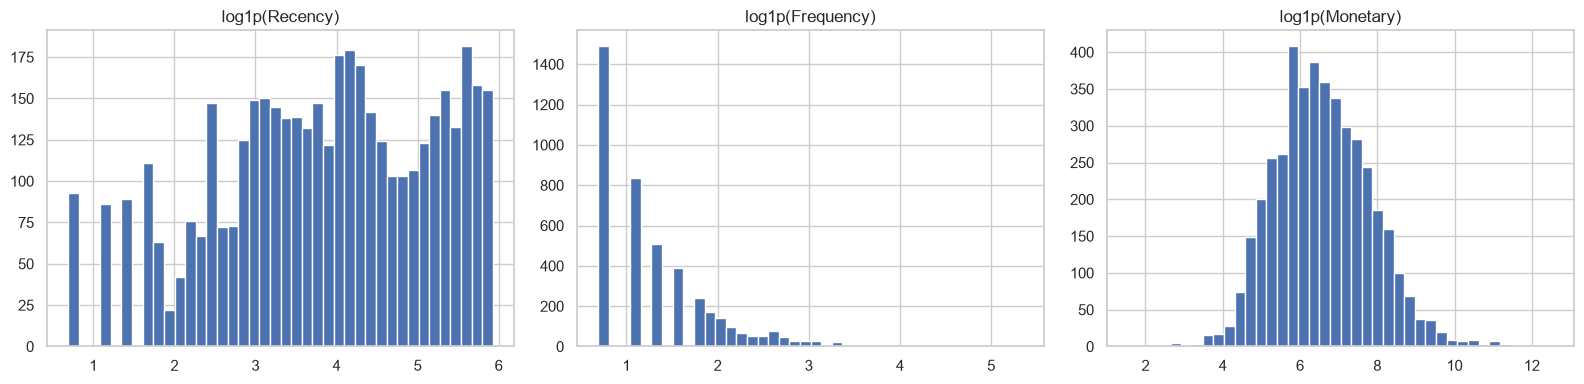

In [32]:
fig, axes = plt.subplots(1, 3, figsize = (16, 4))

axes[0].hist(log_rfm_features["Recency"], bins = 40)
axes[0].set_title("log1p(Recency)")

axes[1].hist(log_rfm_features["Frequency"], bins = 40)
axes[1].set_title("log1p(Frequency)")

axes[2].hist(log_rfm_features["MonetaryValue"], bins = 40)
axes[2].set_title("log1p(Monetary)")

plt.tight_layout()
plt.show()


In [33]:
scaler = StandardScaler()
scaled_rfm_features = scaler.fit_transform(log_rfm_features)

In [34]:
scaled_rfm_df = pd.DataFrame(scaled_rfm_features, 
                             columns = ["Recency_scaled", "Frequency_scaled", "Monetary_scaled"])

In [35]:
print("Means after scaling:")
display(scaled_rfm_df.mean().to_frame("Mean"))

print("Standard deviations after scaling:")
display(scaled_rfm_df.std(ddof = 0).to_frame("Standard Deviation"))

Means after scaling:


,Mean
Recency_scaled,-0.00
Frequency_scaled,-0.00
Monetary_scaled,-0.00


Standard deviations after scaling:


,Standard Deviation
Recency_scaled,1.00
Frequency_scaled,1.00
Monetary_scaled,1.00


The transformed RFM features were standardized to mean 0 and standard deviation 1, ensuring that each feature contributes comparably to K-Means distance calculations.

### Elbow Method

In [36]:
def evaluate_kmeans_clusters(data, min_k = 2, max_k = 10):
    """
    Evaluate different K-Means cluster counts using
    inertia and silhouette score.
    """
    cluster_evaluation = []
    kmeans_models = {}

    for k in range(min_k, max_k + 1):

        kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 20)
        cluster_labels = kmeans.fit_predict(data)

        cluster_evaluation.append({
            "K": k,
            "Inertia": kmeans.inertia_,
            "Silhouette": silhouette_score(data, cluster_labels)
        })

        kmeans_models[k] = kmeans
    cluster_evaluation = pd.DataFrame(cluster_evaluation)

    # Select K with the highest silhouette score
    best_k = int(
        cluster_evaluation.loc[
            cluster_evaluation["Silhouette"].idxmax(), "K"])
    return cluster_evaluation, kmeans_models, best_k

In [37]:
# Evaluate K values from 2 to 10
cluster_evaluation, kmeans_models, best_k = evaluate_kmeans_clusters(
    scaled_rfm_features, min_k = 2, max_k = 10)

display(cluster_evaluation)
print(f"Best K based on silhouette score: {best_k}")

,K,Inertia,Silhouette
0,2,"6,483.59",0.43
1,3,"4,869.49",0.34
2,4,"3,938.60",0.34
3,5,"3,296.71",0.32
4,6,"2,855.53",0.31
5,7,"2,548.82",0.31
6,8,"2,336.34",0.30
7,9,"2,156.01",0.28
8,10,"2,000.57",0.28


Best K based on silhouette score: 2


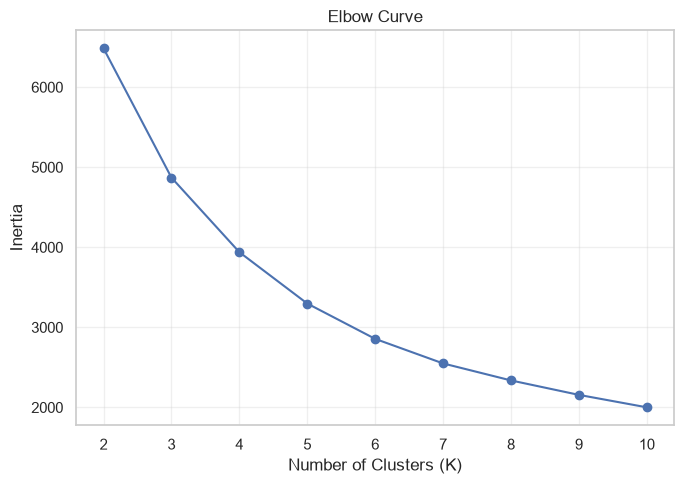

In [38]:
# Elbow curve
plt.figure(figsize = (7, 5))

plt.plot(
    cluster_evaluation["K"], cluster_evaluation["Inertia"], marker = "o")

plt.title("Elbow Curve")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(cluster_evaluation["K"])
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

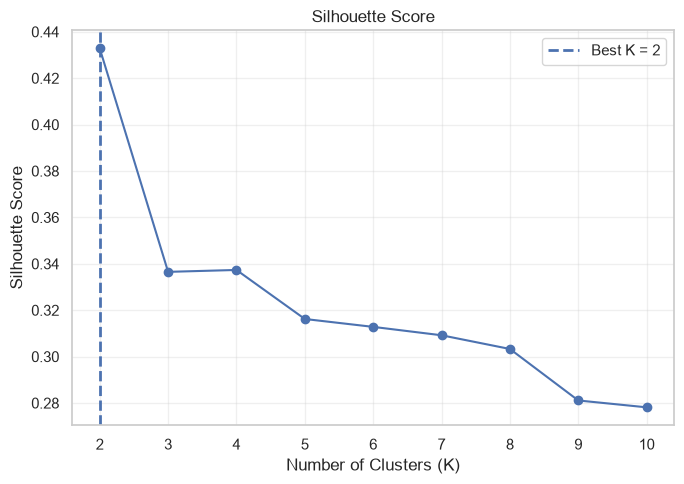

In [39]:
# Silhouette curve
plt.figure(figsize=(7, 5))
plt.plot(cluster_evaluation["K"], cluster_evaluation["Silhouette"], marker = "o")
plt.axvline(best_k, linestyle="--", linewidth = 2,
    label=f"Best K = {best_k}")
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(cluster_evaluation["K"])
plt.grid(True, alpha = 0.3)
plt.legend()
plt.tight_layout()
plt.show()

k = 2 was selected because it produced the highest silhouette score (0.43), while the inertia curve showed a substantial reduction in error at low K values and was consistent with a two-cluster solution.

### Clustering Analysis

In [40]:
# Based on elbow and silhouette, the optimal k is 2
model = KMeans(n_clusters = best_k, random_state = 42, n_init = 20)
model.fit(scaled_rfm_features)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",20
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](2, 3)","[[ 0.

In [41]:
# Assign cluster label to unscaled rfm features.
rfm["Clusters"] = model.labels_
display(rfm["Clusters"].value_counts().sort_index().to_frame("Customers"))

,Customers
Clusters,
0,2672
1,1666


### Cluster Profiling

In [42]:
cluster_profile = (rfm.groupby("Clusters").agg(
           Customers = ("CustomerID", "nunique"),
           Avg_Recency = ("Recency", "mean"),
           Median_Recency = ("Recency", "median"),
           Avg_Frequency = ("Frequency", "mean"),
           Median_Frequency = ("Frequency", "median"),
           Avg_Monetary = ("MonetaryValue", "mean"),
           Median_Monetary = ("MonetaryValue", "median")).reset_index()
)

In [43]:
cluster_profile["CustomerPct"] = (
    cluster_profile["Customers"] / cluster_profile["Customers"].sum() * 100)

In [44]:
cluster_profile

,Clusters,Customers,Avg_Recency,Median_Recency,Avg_Frequency,Median_Frequency,Avg_Monetary,Median_Monetary,CustomerPct
0,0,2672,134.09,96.00,1.67,1.00,495.59,363.07,61.60
1,1,1666,25.89,16.00,8.44,6.00,"4,539.60","2,061.08",38.40


### Simple Insight

* **Cluster 0 (61.6%)**: Larger customer group with **higher recency** and **lower frequency and monetary value**, suggesting **less engaged and lower-value customers**.
* **Cluster 1 (38.4%)**: Smaller but more valuable group with **lower recency, higher frequency, and much higher spending**, suggesting **more active and loyal customers**.

**Overall:** Cluster 1 represents the **high-value/active customers**, while Cluster 0 represents **lower-value or less-engaged customers**.


In [45]:
# Compare each cluster with overall median
profile = rfm.groupby("Clusters")[["Recency", "Frequency", "MonetaryValue"]].median()

In [46]:
overall_median = rfm[["Recency", "Frequency", "MonetaryValue"]].median()

index = profile / overall_median
index

,Recency,Frequency,MonetaryValue
Clusters,,,
0,1.88,0.50,0.54
1,0.31,3.00,3.08


This table shows each cluster **relative to the overall median**:

* **Cluster 0:** Recency is **1.88× the median** (less recent), while Frequency and Monetary are around **0.5× the median**, **lower-value, less-engaged customers**.
* **Cluster 1:** Recency is **0.31× the median** (much more recent), while Frequency and Monetary are **3× the median**, **high-value, highly active customers**.

**Overall:** Cluster 1 is clearly your **best customer segment**.


In [47]:
# Use Standardized cluster profile:
cluster_scaled = pd.DataFrame(
    scaled_rfm_features, columns = ["Recency", "Frequency", "Monetary"])

cluster_scaled["Cluster"] = rfm["Clusters"]
profile = cluster_scaled.groupby("Cluster").mean()

In [48]:
profile

,Recency,Frequency,Monetary
Cluster,,,
0,0.50,-0.60,-0.57
1,-0.81,0.97,0.91


Cluster 0: Higher Recency, but lower Frequency and Monetary, less active, lower-value customers.
Cluster 1: Lower Recency, higher Frequency and Monetary, more active, frequent, and high-value customers.

<Axes: ylabel='Cluster'>

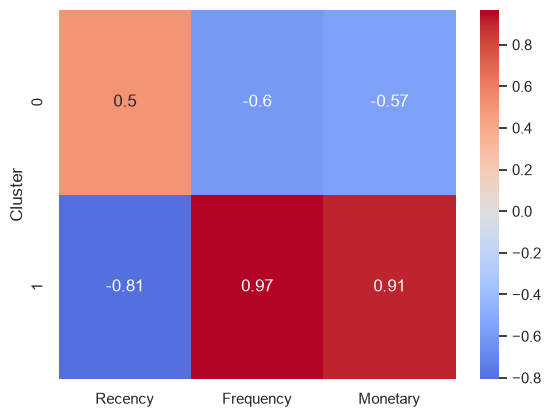

In [49]:
sns.heatmap(profile, annot=True, center=0, cmap="coolwarm")

### Visualization

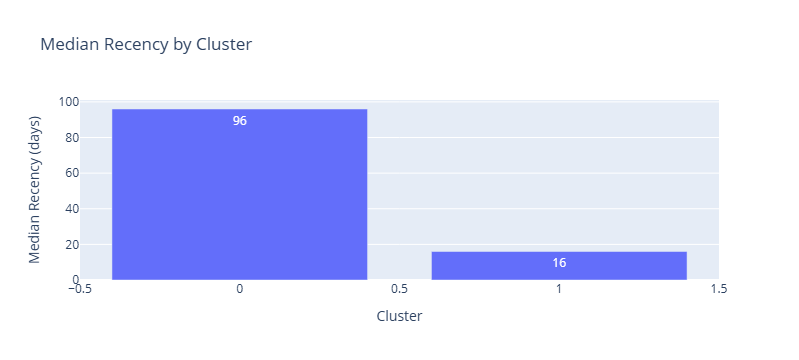

In [50]:
fig = px.bar(cluster_profile, x = "Clusters", y = "Median_Recency",
    text = "Median_Recency", title = "Median Recency by Cluster",
    labels={
        "Clusters": "Cluster",
        "Median_Recency": "Median Recency (days)"})
fig.show()

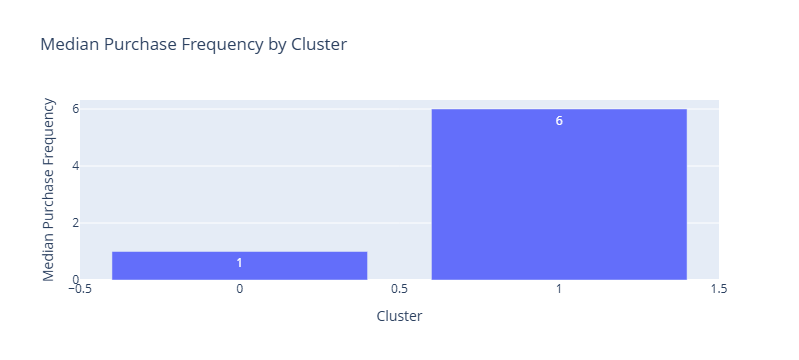

In [51]:
fig = px.bar(cluster_profile, x = "Clusters", y = "Median_Frequency",
    text = "Median_Frequency", title = "Median Purchase Frequency by Cluster",
    labels={
        "Clusters": "Cluster",
        "Median_Frequency": "Median Purchase Frequency"})

fig.show()

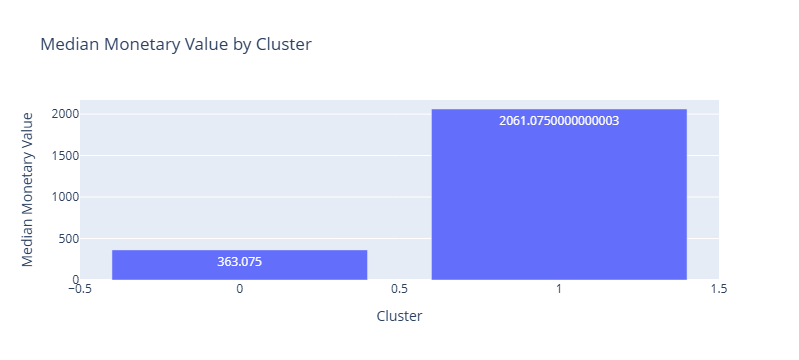

In [52]:
fig = px.bar(cluster_profile, x = "Clusters", y = "Median_Monetary",
    text = "Median_Monetary", title = "Median Monetary Value by Cluster",
    labels={
        "Clusters": "Cluster",
        "Median_Monetary": "Median Monetary Value"
    }
)

fig.show()

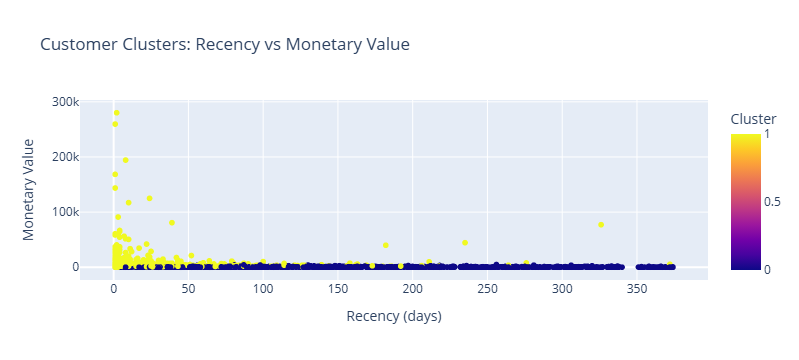

In [53]:
fig = px.scatter(rfm, x = "Recency", y = "MonetaryValue", color = "Clusters",
    hover_data = ["CustomerID", "Frequency"],
    title = "Customer Clusters: Recency vs Monetary Value",
    labels={
        "Recency": "Recency (days)",
        "MonetaryValue": "Monetary Value",
        "Clusters": "Cluster"})

fig.show()

Shows whether clusters separate based on how recently customers purchased and how much they spent.

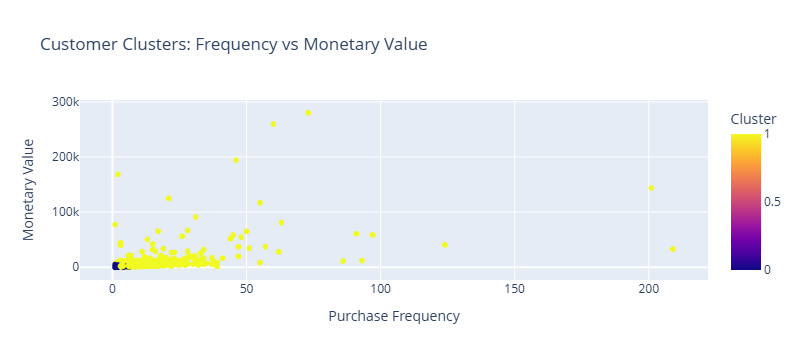

In [54]:
fig = px.scatter(rfm, x = "Frequency", y = "MonetaryValue", color = "Clusters",
    hover_data = ["CustomerID", "Recency"],
    title = "Customer Clusters: Frequency vs Monetary Value",
    labels = {
        "Frequency": "Purchase Frequency",
        "MonetaryValue": "Monetary Value",
        "Clusters": "Cluster"
    }
)

fig.show()

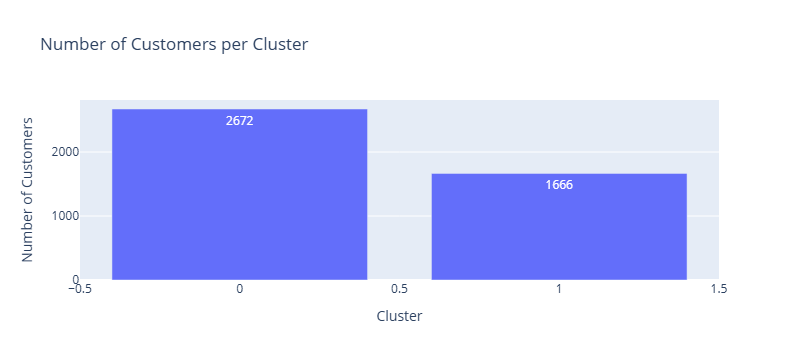

In [55]:
fig = px.bar(rfm["Clusters"].value_counts().sort_index().reset_index(),
    x = "Clusters", y = "count", text = "count",
    title = "Number of Customers per Cluster",
    labels = {
        "Clusters": "Cluster",
        "count": "Number of Customers"})
fig.show()

Shows whether clusters differ based on how often customers purchase and how much they spend.

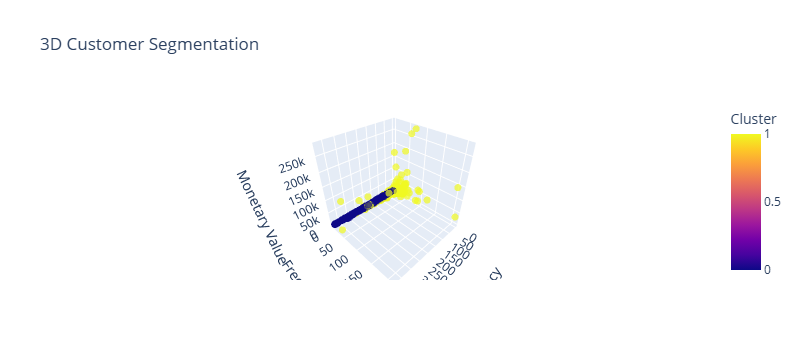

In [56]:
# 3D visualization of customer clusters
fig = px.scatter_3d(rfm, x = "Recency", y = "Frequency", z = "MonetaryValue",
    color = "Clusters",
    hover_data=[
        "CustomerID",
        "Recency",
        "Frequency",
        "MonetaryValue"],
    title = "3D Customer Segmentation",
    labels = {
        "Recency": "Recency (days)",
        "Frequency": "Purchase Frequency",
        "MonetaryValue": "Total Monetary Value",
        "Clusters": "Cluster"}, opacity = 0.7)

fig.update_traces(marker = dict(size = 4))

fig.update_layout(scene = dict(
        xaxis_title = "Recency",
        yaxis_title = "Frequency",
        zaxis_title = "Monetary Value"))
fig.show()

## Recommendation

The business should use the two customer segments differently. Cluster 0 should be targeted with win-back campaigns because these customers purchase less frequently, spend less, and have not purchased recently. Cluster 1 should be focused on retention and loyalty strategies because these customers purchase more frequently, are more recent, and generate higher revenue. This allows the business to focus reactivation efforts on low-engagement customers while protecting and increasing the value of high-value customers.

## Conclusion

The K-Means analysis identified two distinct customer groups based on Recency, Frequency, and Monetary value. Cluster 0 represents a larger group of lower-engagement customers, while Cluster 1 represents a smaller but more active and valuable group. With a silhouette score of 0.43, the K=2 solution provides moderate separation between the clusters. Overall, the segmentation provides a useful basis for applying different marketing strategies to different customer groups.
